In [1]:
import clickhouse_connect

In [2]:
CLICKHOUSE_HOST = '54.234.38.203'
CLICKHOUSE_PORT = 8123
CLICKHOUSE_USER = 'chain8'
CLICKHOUSE_PASS = 'c8_2025'
CLICKHOUSE_DB = 'default'

In [3]:
client = clickhouse_connect.get_client(
    host=CLICKHOUSE_HOST,
    port=CLICKHOUSE_PORT,
    username=CLICKHOUSE_USER,
    password=CLICKHOUSE_PASS,
    database=CLICKHOUSE_DB
)

In [4]:
df_tsx = client.query_df("""
    SELECT *
    FROM tsx_eod
""")

In [5]:
df_AAPL = df_tsx[df_tsx['code']=="AAPL"].copy()

In [6]:
df_AAPL = df_AAPL.sort_values(by='date').reset_index(drop=True)

In [7]:
df_AAPL['exit'] = (
    df_AAPL['open'] * 1.01
).round(2).where(
    df_AAPL['high'] > df_AAPL['open'] * 1.01, 
    df_AAPL['close']
)

In [8]:
df_AAPL['model_return_pct'] = ((df_AAPL['exit'] / df_AAPL['open']) - 1) * 100

In [9]:
df_AAPL

,code,date,open,high,low,close,adjusted_close,volume,created_on,exit,model_return_pct
0,AAPL,2023-01-03,19.64,19.72,18.71,18.86,18.6200,226637,2025-06-27 18:30:29,18.86,-3.971487
1,AAPL,2023-01-04,19.10,19.35,18.87,19.19,18.9458,203925,2025-06-27 18:30:29,19.29,0.994764
2,AAPL,2023-01-05,19.15,19.21,18.82,18.86,18.6200,129233,2025-06-27 18:30:29,18.86,-1.514360
3,AAPL,2023-01-06,19.02,19.60,18.85,19.50,19.2518,181619,2025-06-27 18:30:29,19.21,0.998948
4,AAPL,2023-01-09,19.73,20.09,19.58,19.58,19.3308,92057,2025-06-27 18:30:29,19.93,1.013685
...,...,...,...,...,...,...,...,...,...,...,...
620,AAPL,2025-06-20,28.67,29.19,28.52,29.11,29.1100,274400,2025-06-27 15:25:12,28.96,1.011510
621,AAPL,2025-06-23,29.15,29.26,28.86,29.17,29.1700,129000,2025-06-27 15:25:12,29.17,0.068611
622,AAPL,2025-06-24,29.29,29.42,29.00,29.02,29.0200,192500,2025-06-27 15:25:12,29.02,-0.921816
623,AAPL,2025-06-25,29.15,29.46,29.06,29.19,29.1900,161400,2025-06-27 15:25:12,29.44,0.994854


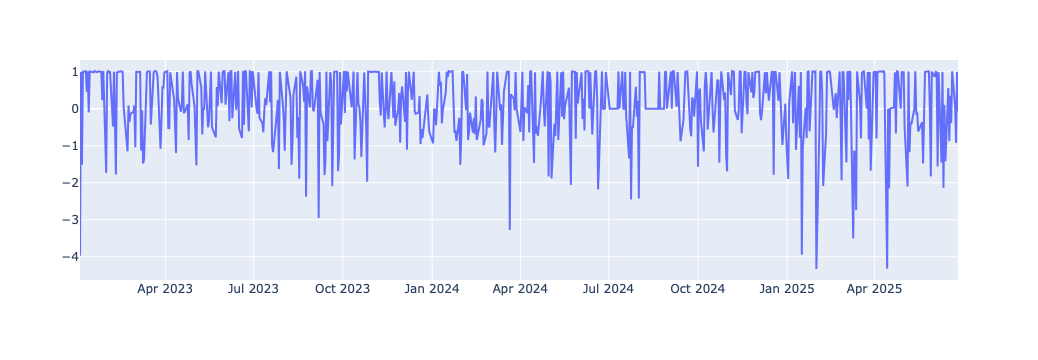

In [10]:
import plotly.express as px

fig = px.line(df_AAPL, x='date', y='model_return_pct')
fig.update_layout(showlegend=False, xaxis_title=None, yaxis_title=None, title=None)
fig.show()

In [11]:
df_AAPL['cumulative_return'] = (1 + df_AAPL['model_return_pct'] / 100).cumprod()

In [12]:
df_AAPL

,code,date,open,high,low,close,adjusted_close,volume,created_on,exit,model_return_pct,cumulative_return
0,AAPL,2023-01-03,19.64,19.72,18.71,18.86,18.6200,226637,2025-06-27 18:30:29,18.86,-3.971487,0.960285
1,AAPL,2023-01-04,19.10,19.35,18.87,19.19,18.9458,203925,2025-06-27 18:30:29,19.29,0.994764,0.969838
2,AAPL,2023-01-05,19.15,19.21,18.82,18.86,18.6200,129233,2025-06-27 18:30:29,18.86,-1.514360,0.955151
3,AAPL,2023-01-06,19.02,19.60,18.85,19.50,19.2518,181619,2025-06-27 18:30:29,19.21,0.998948,0.964692
4,AAPL,2023-01-09,19.73,20.09,19.58,19.58,19.3308,92057,2025-06-27 18:30:29,19.93,1.013685,0.974471
...,...,...,...,...,...,...,...,...,...,...,...,...
620,AAPL,2025-06-20,28.67,29.19,28.52,29.11,29.1100,274400,2025-06-27 15:25:12,28.96,1.011510,1.964769
621,AAPL,2025-06-23,29.15,29.26,28.86,29.17,29.1700,129000,2025-06-27 15:25:12,29.17,0.068611,1.966117
622,AAPL,2025-06-24,29.29,29.42,29.00,29.02,29.0200,192500,2025-06-27 15:25:12,29.02,-0.921816,1.947993
623,AAPL,2025-06-25,29.15,29.46,29.06,29.19,29.1900,161400,2025-06-27 15:25:12,29.44,0.994854,1.967373
